4/4 [==============================] - 0s 3ms/step


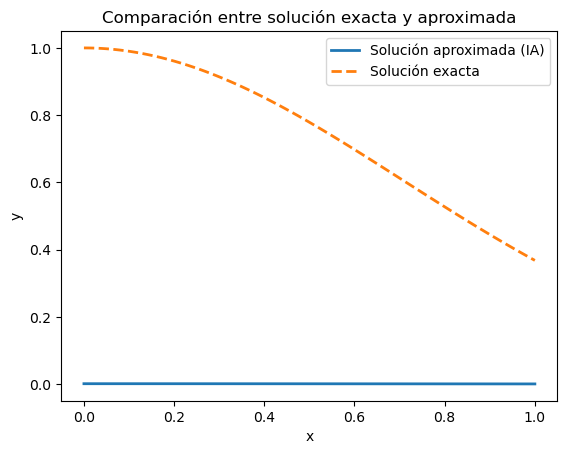

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir la ecuación diferencial
def ode(x, y):
    return -2 * x * y

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='tanh', input_shape=(1,)),  # Capa oculta 1
    tf.keras.layers.Dense(20, activation='tanh'),  # Capa oculta 2
    tf.keras.layers.Dense(1)  # Capa de salida
])

# Función de pérdida personalizada
def custom_loss(x, y_pred):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)
    dy_dx = tape.gradient(y_pred, x)
    return tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))

# Compilar el modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss=custom_loss)

# Datos de entrenamiento
x_train = np.linspace(0, 1, 100).reshape(-1, 1)
y_train = np.exp(-x_train**2)  # Solución exacta para comparación

# Entrenar el modelo
history = model.fit(x_train, y_train, epochs=2000, verbose=0)

# Predecir la solución
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_pred = model.predict(x_test)

# Graficar la solución
plt.plot(x_test, y_pred, label='Solución aproximada (IA)', linestyle='-', linewidth=2)
plt.plot(x_test, np.exp(-x_test**2), label='Solución exacta', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparación entre solución exacta y aproximada')
plt.show()

Epoch 0, Loss: 0.434894323348999
Epoch 200, Loss: 1.6746220353525132e-05
Epoch 400, Loss: 2.0559841686917935e-06
Epoch 600, Loss: 2.1091173607601377e-07
Epoch 800, Loss: 1.1016232548399785e-07
Epoch 1000, Loss: 1.069691393240646e-07
Epoch 1200, Loss: 1.0603262268205071e-07
Epoch 1400, Loss: 1.0499921643258858e-07
Epoch 1600, Loss: 1.0383560322679841e-07
Epoch 1800, Loss: 1.0253877746890794e-07
4/4 [==============================] - 0s 5ms/step


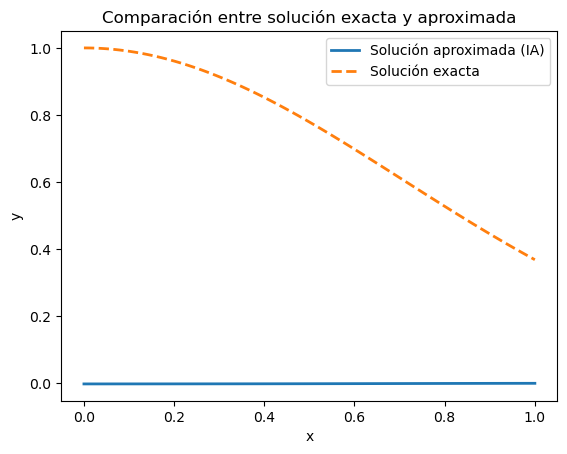

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir la ecuación diferencial
def ode(x, y):
    return -2 * x * y

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='tanh', input_shape=(1,)),  # Capa oculta 1
    tf.keras.layers.Dense(20, activation='tanh'),  # Capa oculta 2
    tf.keras.layers.Dense(1)  # Capa de salida
])

# Función de pérdida personalizada
def custom_loss(y_true, y_pred):
    x = tf.convert_to_tensor(y_true, dtype=tf.float32)  # Convertir x a tensor
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)  # Volver a calcular y_pred en el contexto del tape
    dy_dx = tape.gradient(y_pred, x)  # Calcular la derivada
    return tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))  # Pérdida basada en la ODE

# Compilar el modelo
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Datos de entrenamiento
x_train = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)

# Función de entrenamiento personalizada
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss_value = custom_loss(x_train, model(x_train))
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

# Entrenamiento manual
epochs = 2000
for epoch in range(epochs):
    loss = train_step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predecir la solución
x_test = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)

# Graficar la solución
plt.plot(x_test, y_pred, label='Solución aproximada (IA)', linestyle='-', linewidth=2)
plt.plot(x_test, np.exp(-x_test**2), label='Solución exacta', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparación entre solución exacta y aproximada')
plt.show()

Epoch 0, Loss: 0.8449038863182068
Epoch 200, Loss: 1.2453896488295868e-05
Epoch 400, Loss: 1.7652080259722425e-06
Epoch 600, Loss: 1.4952210847241076e-07
Epoch 800, Loss: 2.4582913482618096e-08
Epoch 1000, Loss: 1.9527165662225343e-08
Epoch 1200, Loss: 1.9361261038852717e-08
Epoch 1400, Loss: 1.9279900342894507e-08
Epoch 1600, Loss: 1.918763281594238e-08
Epoch 1800, Loss: 1.9082170510387186e-08
4/4 [==============================] - 0s 2ms/step


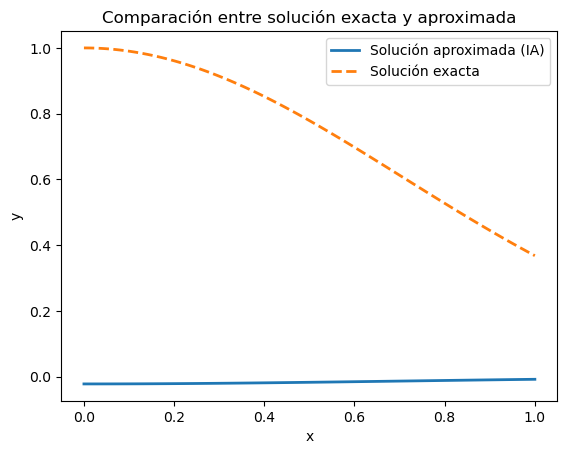

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir la ecuación diferencial dy/dx = -2xy
def ode(x, y):
    return -2 * x * y

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='tanh', input_shape=(1,)),  # Capa oculta 1
    tf.keras.layers.Dense(20, activation='tanh'),  # Capa oculta 2
    tf.keras.layers.Dense(1)  # Capa de salida
])

# Función de pérdida basada en la ecuación diferencial
def custom_loss(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)  # Calcular la salida de la red
    dy_dx = tape.gradient(y_pred, x)  # Calcular la derivada de y respecto a x
    return tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))  # Minimizar el error de la ecuación diferencial

# Optimizador
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Datos de entrenamiento
x_train = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
x_train = tf.Variable(x_train)  # Convertir a Variable de TensorFlow para permitir gradientes

# Función de entrenamiento personalizada
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss_value = custom_loss(x_train)
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

# Entrenamiento manual
epochs = 2000
for epoch in range(epochs):
    loss = train_step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predecir la solución
x_test = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)

# Graficar la solución
plt.plot(x_test, y_pred, label='Solución aproximada (IA)', linestyle='-', linewidth=2)
plt.plot(x_test, np.exp(-x_test**2), label='Solución exacta', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparación entre solución exacta y aproximada')
plt.show()



Epoch 0, Loss: 1.3651539087295532
Epoch 500, Loss: 0.00019702420104295015
Epoch 1000, Loss: 0.00010717121040215716
Epoch 1500, Loss: 7.769778312649578e-05
Epoch 2000, Loss: 6.277676584431902e-05
Epoch 2500, Loss: 5.259129829937592e-05
Epoch 3000, Loss: 7.199226092780009e-05
Epoch 3500, Loss: 3.940560054616071e-05
Epoch 4000, Loss: 3.4794251405401155e-05
Epoch 4500, Loss: 3.0128800062811933e-05
4/4 [==============================] - 0s 3ms/step


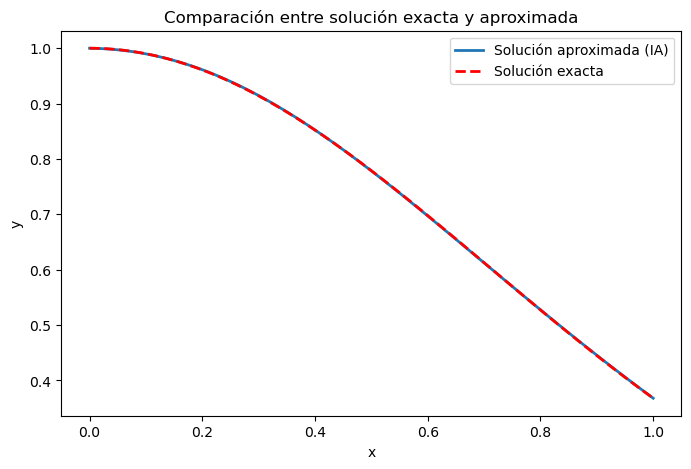

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Definir la ecuación diferencial dy/dx = -2xy
def ode(x, y):
    return -2 * x * y

# Definir la red neuronal con más capas y unidades
model = tf.keras.Sequential([
    tf.keras.layers.Dense(40, activation='tanh', input_shape=(1,)),  # Capa oculta 1
    tf.keras.layers.Dense(40, activation='tanh'),  # Capa oculta 2
    tf.keras.layers.Dense(40, activation='tanh'),  # Capa oculta 3
    tf.keras.layers.Dense(1)  # Capa de salida
])

# Función de pérdida basada en la ecuación diferencial
def custom_loss(x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        y_pred = model(x)  # Salida de la red neuronal
    dy_dx = tape.gradient(y_pred, x)  # Derivada de la red respecto a x
    return tf.reduce_mean(tf.square(dy_dx - ode(x, y_pred)))  # Minimizar el error de la ecuación diferencial

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Datos de entrenamiento (convertidos a Variable para cálculo de gradientes)
x_train = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
x_train = tf.Variable(x_train)

# Condición inicial y(0) = 1
x_0 = tf.convert_to_tensor([[0.0]], dtype=tf.float32)
y_0 = tf.convert_to_tensor([[1.0]], dtype=tf.float32)

# Función de entrenamiento personalizada
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss_value = custom_loss(x_train)
        # Penalización por la condición inicial
        y_pred_0 = model(x_0)
        loss_value += tf.reduce_mean(tf.square(y_pred_0 - y_0))
    
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

# Entrenamiento manual
epochs = 5000
for epoch in range(epochs):
    loss = train_step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predecir la solución
x_test = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)

# Graficar la solución
plt.figure(figsize=(8, 5))
plt.plot(x_test, y_pred, label='Solución aproximada (IA)', linestyle='-', linewidth=2)
plt.plot(x_test, np.exp(-x_test**2), label='Solución exacta', linestyle='--', linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparación entre solución exacta y aproximada')
plt.show()

